# Understanding the Kalman Filter for an IMU — From Zero

**A teaching notebook.** This is written for someone who has *never* studied Kalman filtering, is comfortable with basic maths, knows a little statistics, and has already done an **Allan-variance** analysis of their IMU. We build every idea slowly, in plain language, and only use the statistics you actually need (we even define the "expectation" symbol when it shows up).

By the end you will understand:
1. What a Kalman filter *is* and *why* it works (not just the equations).
2. How to build one — first in 1 dimension, then with matrices.
3. **How the numbers from your Allan-variance plot (ARW/VRW, RRW, bias instability) turn into the filter's `Q` and `R` matrices.**
4. What a **quaternion** is, how to create one, and why we use it for orientation.
5. How the **EKF** and **UKF** extend the filter to the (nonlinear) IMU orientation problem.

### How to read it
Go top to bottom and **run every code cell** (Shift+Enter). Each cell is short and tied to the text right above it. Nothing is assumed from earlier notebooks. Needs only `numpy`, `scipy`, `matplotlib`.

> **Mental model to keep in your head the whole time:**
> A Kalman filter keeps a *guess* and a *measure of how unsure it is about that guess*. Every step it does two things — **predict** (move the guess forward using a model, becoming a bit more unsure) and **correct** (pull the guess toward a new measurement, becoming more sure). That's the entire idea. Everything else is bookkeeping.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)
plt.rcParams['figure.figsize'] = (9, 3.5)
DEG = 180/np.pi
print("Ready. Run the cells in order.")

Ready. Run the cells in order.


# Part A — The little bit of statistics you need

We need exactly three ideas: the **average**, the **variance**, and the **Gaussian**. If you know these, skip to Part B — but the "expectation" symbol $E[\cdot]$ is explained here because it appears in the Kalman equations.

## A1. Average, the expectation symbol $E[\cdot]$, and variance

Imagine your gyroscope is lying still. The true rate is $0$, but each reading is a bit off because of noise. If you collect many readings and take their **average**, you get (almost) the true value. That "long-run average" is all the symbol $E[\cdot]$ means:

$$E[X] \;=\; \text{the average value of } X \text{ if you repeated the measurement forever.}$$

So $E[X]$ is just the **mean**, written in a fancy way. Read "$E[X]$" as *"the average of X."*

The **variance** measures how *spread out* the readings are around that average — i.e. how noisy/uncertain they are:

$$\operatorname{Var}(X) \;=\; E\big[(X - \text{mean})^2\big] \;=\; \text{the average of the squared distance from the mean.}$$

Its square root is the **standard deviation** $\sigma$ (same units as the signal). **Big variance = very unsure. Small variance = confident.** This single idea — *variance means uncertainty* — is the heart of the Kalman filter.

E[X]  (the average)      : -0.0002  <- close to the true 0
Var(X)(average sq. dist.): 0.00248
sigma (std deviation)    : 0.0498  <- close to the true 0.05


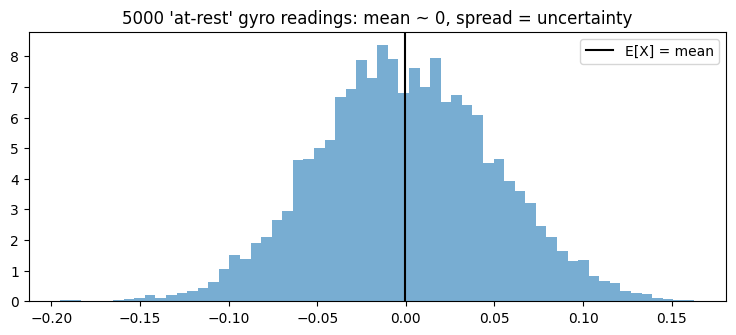

In [4]:
# A noisy gyro at rest: true value 0, noise standard deviation 0.05 rad/s
readings = rng.normal(0.0, 0.05, size=5000)

print("E[X]  (the average)      :", np.mean(readings).round(4), " <- close to the true 0")
print("Var(X)(average sq. dist.):", np.var(readings).round(5))
print("sigma (std deviation)    :", np.std(readings).round(4), " <- close to the true 0.05")

plt.hist(readings, bins=60, density=True, alpha=.6)
plt.axvline(np.mean(readings), color='k', label='E[X] = mean')
plt.title("5000 'at-rest' gyro readings: mean ~ 0, spread = uncertainty"); plt.legend(); plt.show()

## A2. The Gaussian — our way of writing "a guess with an uncertainty"

The bell curve (**Gaussian / normal distribution**) is the perfect container for a Kalman filter's belief, because it is fully described by just **two numbers**: the mean $\mu$ (our best guess) and the variance $\sigma^2$ (how unsure we are). We write it $\mathcal N(\mu,\sigma^2)$.

- Narrow tall bell = small variance = **confident**.
- Wide flat bell = large variance = **unsure**.
- Rule of thumb: ~68% of values land within $\pm 1\sigma$, ~95% within $\pm 2\sigma$.

The whole Kalman filter is just *moving a bell curve around and changing its width.*

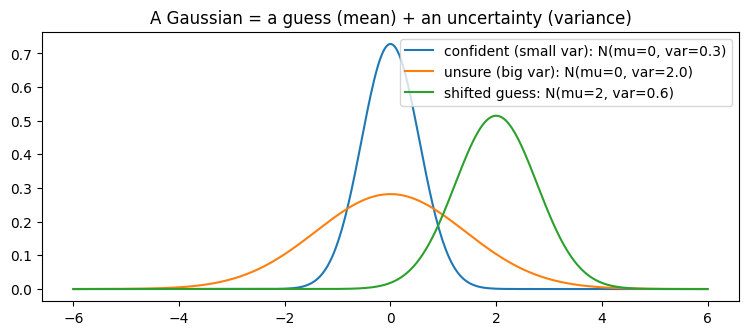

In [5]:
def gaussian(x, mu, var):
    return np.exp(-0.5*(x-mu)**2/var) / np.sqrt(2*np.pi*var)

x = np.linspace(-6, 6, 400)
for mu, var, lab in [(0, 0.3, 'confident (small var)'), (0, 2.0, 'unsure (big var)'), (2, 0.6, 'shifted guess')]:
    plt.plot(x, gaussian(x, mu, var), label=f'{lab}: N(mu={mu}, var={var})')
plt.title("A Gaussian = a guess (mean) + an uncertainty (variance)"); plt.legend(); plt.show()

## A3. The two operations the filter ever does to a Gaussian

**(1) Multiply two Gaussians → a new, narrower Gaussian.** This is how we *combine* two independent pieces of information about the same thing (e.g. a prediction and a measurement). The result is *more certain than either input* — combining information always reduces uncertainty:

$$\mu = \frac{\sigma_2^2\,\mu_1 + \sigma_1^2\,\mu_2}{\sigma_1^2+\sigma_2^2}, \qquad
\sigma^2 = \frac{\sigma_1^2\,\sigma_2^2}{\sigma_1^2+\sigma_2^2}.$$

Notice the new mean is a **weighted average**: the source with smaller variance (more trustworthy) pulls the result toward itself. *Remember this — it is literally the Kalman update.*

**(2) Add two Gaussians → a wider Gaussian.** This is how we account for *motion with imperfect knowledge*: we shift the guess and it becomes **less certain**:

$$\mu = \mu_1+\mu_2, \qquad \sigma^2 = \sigma_1^2+\sigma_2^2.$$

combined guess: mean=12.40, var=0.80  (pulled toward the more trustworthy 13, and NARROWER than both inputs)


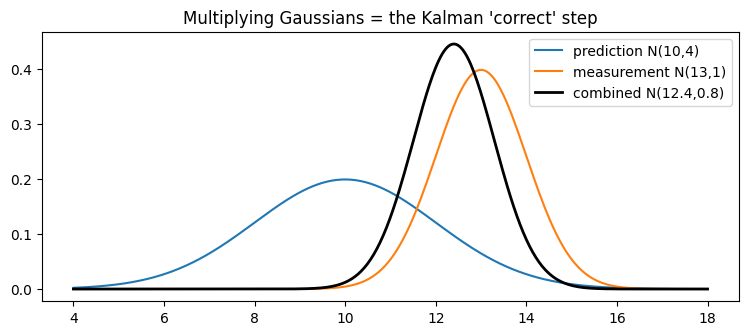

In [6]:
def gaussian_multiply(m1, v1, m2, v2):     # combine two beliefs -> sharper
    m = (v2*m1 + v1*m2) / (v1+v2)
    v = (v1*v2) / (v1+v2)
    return m, v

prior_m, prior_v = 10.0, 4.0       # our prediction:  guess 10, fairly unsure
meas_m,  meas_v  = 13.0, 1.0       # a measurement:   reads 13, quite trustworthy
post_m, post_v = gaussian_multiply(prior_m, prior_v, meas_m, meas_v)
print(f"combined guess: mean={post_m:.2f}, var={post_v:.2f}  "
      f"(pulled toward the more trustworthy 13, and NARROWER than both inputs)")

x = np.linspace(4, 18, 400)
plt.plot(x, gaussian(x, prior_m, prior_v), label='prediction N(10,4)')
plt.plot(x, gaussian(x, meas_m, meas_v),  label='measurement N(13,1)')
plt.plot(x, gaussian(x, post_m, post_v), 'k', lw=2, label=f'combined N({post_m:.1f},{post_v:.1f})')
plt.title("Multiplying Gaussians = the Kalman 'correct' step"); plt.legend(); plt.show()

# Part B — The Kalman filter itself

## B1. The predict–correct loop

A Kalman filter repeats two steps forever:

```
   ┌──────────┐   prediction (a Gaussian)    ┌──────────┐
   │ PREDICT  │ ───────────────────────────► │ CORRECT  │
   │ use model│                              │ use a    │
   │ (gyro)   │ ◄─────────────────────────── │ measure  │
   └──────────┘   corrected belief           └──────────┘
```

- **Predict:** push the belief forward with a model of how things move. Uses operation **(2)** (add) → uncertainty **grows**.
- **Correct:** combine with a fresh measurement. Uses operation **(1)** (multiply) → uncertainty **shrinks**.

For an IMU: *predict* with the gyroscope (it tells you how you're turning), *correct* with the accelerometer/magnetometer (they tell you which way is down/north). That's it.

## B2. The 1-D Kalman filter (one number)

Let's filter a single value. The belief is a Gaussian: a guess `x` and its variance `P`.

**Predict** — apply known motion `u` (e.g. "we expect to move +1"), with model-uncertainty `Q` (the *process noise* — how wrong the motion model might be):
$$\bar x = x + u, \qquad \bar P = P + Q.$$

**Correct** — fold in measurement `z` with sensor-variance `R` (the *measurement noise*). Rewriting the "multiply two Gaussians" formula gives the famous form:
$$y = z - \bar x \;\;(\text{the surprise}),\qquad K = \frac{\bar P}{\bar P + R}\;\;(\text{the Kalman gain}),$$
$$x = \bar x + K\,y, \qquad P = (1-K)\,\bar P.$$

**Understand the gain `K`** (a number between 0 and 1): it is *how much you trust the measurement vs. the prediction.*
- Sensor very good (`R` small) → `K → 1` → jump to the measurement.
- Prediction very good (`P` small) → `K → 0` → keep the prediction.

`K` is exactly the "weight" from the weighted average in A3 — the filter computes it automatically every step.

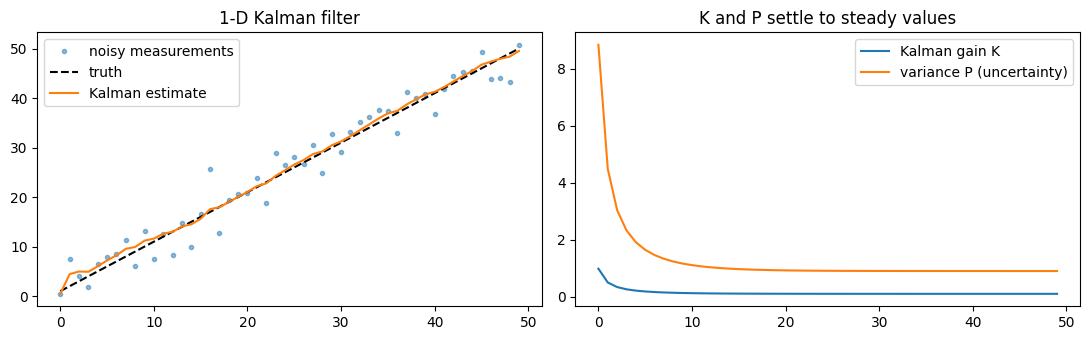

In [7]:
def kalman_1d(zs, x, P, u, Q, R):
    xs, Ps, Ks = [], [], []
    for z in zs:
        # PREDICT
        x = x + u
        P = P + Q
        # CORRECT
        y = z - x                 # surprise / residual
        K = P / (P + R)           # Kalman gain: how much to trust the measurement
        x = x + K*y
        P = (1 - K)*P
        xs.append(x); Ps.append(P); Ks.append(K)
    return np.array(xs), np.array(Ps), np.array(Ks)

# Truth moves +1 each step; sensor is noisy (variance 9 -> std 3).
N = 50
truth = np.cumsum(np.ones(N))
zs = truth + rng.normal(0, 3, N)
xs, Ps, Ks = kalman_1d(zs, x=0.0, P=500.0, u=1.0, Q=0.1, R=9)


fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(zs, '.', alpha=.5, label='noisy measurements')
ax[0].plot(truth, 'k--', label='truth'); ax[0].plot(xs, label='Kalman estimate')
ax[0].legend(); ax[0].set_title('1-D Kalman filter')
ax[1].plot(Ks, label='Kalman gain K'); ax[1].plot(Ps, label='variance P (uncertainty)')
ax[1].legend(); ax[1].set_title('K and P settle to steady values'); plt.tight_layout(); plt.show()

**Things to notice (run the cell, then re-read):**
- We started with a *terrible* guess (`x=0`) and *huge* uncertainty (`P=500`). The filter recovers almost immediately — because honest big uncertainty makes `K≈1` at first, so it trusts the data until it's confident.
- `K` and `P` **drop and level off**. Once the filter "warms up", it settles into a steady trust level between model and sensor.
- If you set `R` smaller, the estimate hugs the noisy dots more (if R is smaller than Q) (twitchy). Larger `R` → smoother but laggier (because to reduce the varriance we need to increase the filtering aka larger filter window more lag). **This trade-off is the thing you tune.**

## B3. More than one number: state vectors and the covariance matrix

An IMU needs to track several things at once (orientation, gyro bias, …). So the single guess `x` becomes a **vector** $\mathbf x$, and the single variance `P` becomes a **covariance matrix** $\mathbf P$:

$$\mathbf P = \begin{bmatrix}\sigma_1^2 & \sigma_{12}\\ \sigma_{12} & \sigma_2^2\end{bmatrix}.$$

- The **diagonal** entries are the variances (uncertainty) of each state variable.
- The **off-diagonal** entries are **covariances** — *how two variables are correlated*, i.e. do they tend to be wrong together?

**Why off-diagonals are the secret sauce.** Suppose you only *measure position* but your state also has *velocity*. After a few steps, the filter notices that position errors and velocity errors move together, and stores that link in the off-diagonal. From then on, a position measurement also corrects the velocity **you never measured**.

> For an IMU this is exactly how the filter estimates **gyro bias** (which no sensor measures directly): over time the bias error becomes correlated with the orientation error that the accelerometer *does* reveal, so the filter can back it out. This is why a Kalman filter beats a simple complementary filter.

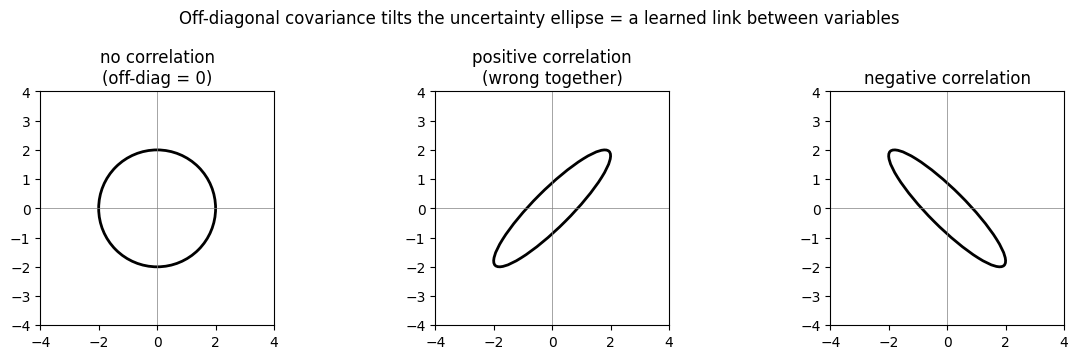

In [8]:
# Picture a covariance matrix as an uncertainty ellipse.
from matplotlib.patches import Ellipse
def draw_cov(ax, cov, title):
    vals, vecs = np.linalg.eigh(cov)
    ang = np.degrees(np.arctan2(vecs[1,1], vecs[0,1]))
    w, h = 2*np.sqrt(vals[::-1])
    ax.add_patch(Ellipse((0,0), 2*w, 2*h, angle=ang, fill=False, lw=2))
    ax.set_xlim(-4,4); ax.set_ylim(-4,4); ax.axhline(0,c='gray',lw=.5); ax.axvline(0,c='gray',lw=.5)
    ax.set_title(title); ax.set_aspect('equal')

fig, ax = plt.subplots(1, 3, figsize=(12, 3.6))
draw_cov(ax[0], np.array([[1,0],[0,1.]]),      "no correlation\n(off-diag = 0)")
draw_cov(ax[1], np.array([[1,0.9],[0.9,1.]]),  "positive correlation\n(wrong together)")
draw_cov(ax[2], np.array([[1,-0.9],[-0.9,1.]]),"negative correlation")
plt.suptitle("Off-diagonal covariance tilts the uncertainty ellipse = a learned link between variables")
plt.tight_layout(); plt.show()

## B4. The eight Kalman equations — explained one symbol at a time

These are just B2 (the 1-D filter) rewritten with matrices so they handle vectors. **You do not need to memorise the algebra** — you need to know *what each letter is* and *which ones you design*.

**Predict**
$$\bar{\mathbf x} = \mathbf F\mathbf x + \mathbf B\mathbf u \qquad\qquad \bar{\mathbf P} = \mathbf F\mathbf P\mathbf F^{\top} + \mathbf Q$$

**Correct**
$$\mathbf y = \mathbf z - \mathbf H\bar{\mathbf x}\quad(\text{surprise}) \qquad \mathbf S = \mathbf H\bar{\mathbf P}\mathbf H^{\top}+\mathbf R\quad(\text{surprise's uncertainty})$$
$$\mathbf K = \bar{\mathbf P}\mathbf H^{\top}\mathbf S^{-1}\quad(\text{gain}) \qquad \mathbf x = \bar{\mathbf x}+\mathbf K\mathbf y \qquad \mathbf P = (\mathbf I-\mathbf K\mathbf H)\bar{\mathbf P}$$

| Symbol | Plain-English meaning | Who decides it |
|--------|----------------------|----------------|
| $\mathbf x$ | the state: what you're estimating | you choose the variables |
| $\mathbf P$ | covariance: how unsure you are | you set the start, filter updates it |
| $\mathbf F$ | "how the state moves in one step" (the physics) | **you design** |
| $\mathbf Q$ | process noise: how much you distrust $\mathbf F$ | **you design (← Allan!)** |
| $\mathbf B,\mathbf u$ | known control input (often unused) | you |
| $\mathbf H$ | "what a sensor sees, given the state" | **you design** |
| $\mathbf R$ | measurement noise: how noisy the sensor is | **you design (← calibration)** |
| $\mathbf z$ | the actual sensor reading | comes in live |
| $\mathbf K$ | gain: trust split between model and sensor | computed for you |

Compare to the 1-D version: $\mathbf F\leftrightarrow 1$, $\mathbf H\leftrightarrow 1$, and $\mathbf K=\bar{\mathbf P}\mathbf H^\top\mathbf S^{-1}$ is exactly $K=\bar P/(\bar P+R)$. **Same idea, just matrices.**

The cell below is a complete, readable Kalman filter in ~12 lines.

In [9]:
class KalmanFilter:
    def __init__(self, dim_x, dim_z):
        self.x = np.zeros(dim_x)         # state guess
        self.P = np.eye(dim_x)           # uncertainty
        self.F = np.eye(dim_x)           # motion model
        self.Q = np.eye(dim_x)           # process noise (model distrust)
        self.H = np.zeros((dim_z, dim_x))# sensor model
        self.R = np.eye(dim_z)           # sensor noise
        self._I = np.eye(dim_x)
    def predict(self):
        self.x = self.F @ self.x
        self.P = self.F @ self.P @ self.F.T + self.Q
    def correct(self, z):
        y = z - self.H @ self.x                      # surprise
        S = self.H @ self.P @ self.H.T + self.R      # its uncertainty
        K = self.P @ self.H.T @ np.linalg.inv(S)     # gain
        self.x = self.x + K @ y
        self.P = (self._I - K @ self.H) @ self.P
        return y
print("KalmanFilter ready (this is the whole algorithm).")

KalmanFilter ready (this is the whole algorithm).


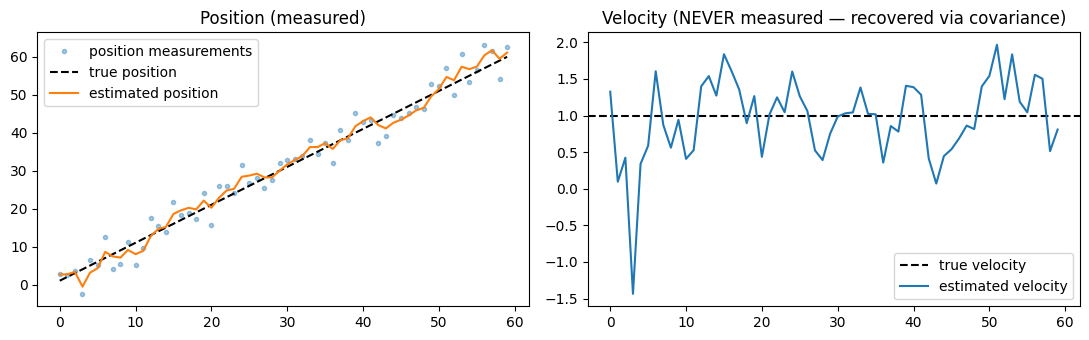

In [10]:
# Demo of the 'hidden variable' magic: measure ONLY position, recover velocity too.
dt = 1.0
kf = KalmanFilter(dim_x=2, dim_z=1)        # state = [position, velocity]
kf.x = np.array([0., 0.])
kf.P = np.diag([500., 500.])               # we know almost nothing at the start
kf.F = np.array([[1, dt],                   # new_pos = pos + vel*dt
                 [0, 1.]])                  # new_vel = vel
kf.H = np.array([[1., 0.]])                # the sensor sees position only
kf.R = np.array([[10.]])                   # sensor noise
kf.Q = 0.2*np.array([[dt**3/3, dt**2/2],   # process noise (more on this in Part C)
                     [dt**2/2, dt]])

truth_p = np.cumsum(np.ones(60))           # true velocity = 1
zs = truth_p + rng.normal(0, np.sqrt(10), 60)
est = []
for z in zs:
    kf.predict(); kf.correct(np.array([z])); est.append(kf.x.copy())
est = np.array(est)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(zs, '.', alpha=.4, label='position measurements'); ax[0].plot(truth_p,'k--',label='true position')
ax[0].plot(est[:,0], label='estimated position'); ax[0].legend(); ax[0].set_title('Position (measured)')
ax[1].axhline(1, ls='--', color='k', label='true velocity')
ax[1].plot(est[:,1], label='estimated velocity'); ax[1].legend()
ax[1].set_title('Velocity (NEVER measured — recovered via covariance)'); plt.tight_layout(); plt.show()

# Part C — From your Allan-variance results to `Q` and `R`

This is the part you specifically asked about. You already have your sensor's noise numbers; here is **what they mean** and **exactly where they plug in**.

## C1. The IMU error model (what the Allan plot is measuring)

For one axis of a gyro (an accel is identical), the standard model is:
$$\underbrace{\tilde\omega}_{\text{reading}} = \underbrace{\omega}_{\text{truth}} + \underbrace{b}_{\text{slowly drifting bias}} + \underbrace{n}_{\text{fast white noise}}.$$

Your Allan-deviation curve separates these by their **slope** on the log–log plot:

| Allan region | Slope | Noise it identifies | Gyro name | Accel name |
|--------------|-------|---------------------|-----------|------------|
| left, falling | **−1/2** | white noise on the rate | **ARW** (Angle Random Walk) | **VRW** (Velocity Random Walk) |
| flat bottom | **0** | bias wandering slowly | **Bias Instability** $B$ | Bias Instability |
| right, rising | **+1/2** | random walk of the bias | **RRW** (Rate Random Walk) | Accel RRW |

So your Allan analysis already handed you the two things the filter needs: **how fast the readings jitter (white noise)** and **how fast the bias drifts**.

## C2. The one conversion rule you must respect: continuous ↔ discrete

Datasheets/Allan give noise **densities** (per √Hz), but your filter runs in discrete steps of $\Delta t = 1/f_s$. The conversion (from the Kalibr IMU model) is:

$$\underbrace{\sigma_{\text{white},d} = \frac{\sigma_{\text{white}}}{\sqrt{\Delta t}}}_{\text{white noise}}\qquad\qquad
\underbrace{\sigma_{\text{bias},d} = \sigma_{\text{bias}}\sqrt{\Delta t}}_{\text{bias random walk}}$$

Intuition: white noise *averages out* when you sample faster (so faster sampling → smaller per-sample effect when integrated), while the bias random-walk *accumulates* over time.

- $\sigma_{\text{white}}$ comes from **ARW** (gyro) or **VRW** (accel).
- $\sigma_{\text{bias}}$ comes from **RRW** (or is approximated from the **bias-instability** floor).

In [11]:
def to_discrete_white(sigma_density, dt):      # ARW / VRW  ->  per-step white-noise std
    return sigma_density / np.sqrt(dt)
def to_discrete_biaswalk(sigma_bias, dt):      # RRW        ->  per-step bias-walk std
    return sigma_bias * np.sqrt(dt)

# --- Example placeholders. Replace with YOUR Allan numbers (mind the units!). ---
fs = 200.0; dt = 1/fs
arw_gyro   = 0.004     # gyro white-noise density  [rad/s/sqrt(Hz)]  (from ARW)
rrw_gyro   = 1e-4      # gyro bias random walk     [rad/s^2/sqrt(Hz)](from RRW)
vrw_acc    = 0.02      # accel white-noise density [m/s^2/sqrt(Hz)]  (from VRW)

print("per-step gyro white-noise std :", round(to_discrete_white(arw_gyro, dt), 5), "rad/s")
print("per-step gyro bias-walk  std  :", to_discrete_biaswalk(rrw_gyro, dt), "rad/s")
print("per-step accel white-noise std:", round(to_discrete_white(vrw_acc, dt), 5), "m/s^2")

per-step gyro white-noise std : 0.05657 rad/s
per-step gyro bias-walk  std  : 7.0710678118654756e-06 rad/s
per-step accel white-noise std: 0.28284 m/s^2


## C3. Building `Q` (process noise) from those numbers

`Q` describes how much uncertainty the *predict* step adds. For an orientation filter the state splits in two, and so does `Q`:

**(a) Orientation states** are driven forward by the gyro, so their uncertainty grows with the **gyro white noise**. The variance added to the angle over one step is
$$Q_{\text{angle}} \approx \sigma_{\text{white}}^2\,\Delta t \quad=\quad \text{ARW}^2 \cdot \Delta t .$$
(Integrating rate-noise for a time $\Delta t$ gives an angle whose variance is the noise PSD times $\Delta t$ — that *is* "angle random walk".)

**(b) Bias states** drift as a random walk, so their uncertainty grows with the **bias random walk**:
$$Q_{\text{bias}} \approx \sigma_{\text{bias}}^2\,\Delta t \quad=\quad \text{RRW}^2 \cdot \Delta t .$$

So the process-noise matrix is block-diagonal — gyro ARW feeds the orientation block, gyro RRW (or bias instability) feeds the bias block:
$$\mathbf Q = \operatorname{diag}\big(\;\underbrace{\sigma_{\text{white}}^2\Delta t,\;\dots}_{\text{orientation}},\;\;\underbrace{\sigma_{\text{bias}}^2\Delta t,\;\dots}_{\text{gyro bias}}\;\big).$$

> **Tuning reality:** the Allan numbers give an excellent *starting point*. Because the model ignores temperature, vibration, etc., people usually **inflate `Q` by 2–10×** until the filter behaves (Part F shows how to check). But you now know what each entry physically represents.

In [12]:
def build_Q(arw, rrw, dt, n_orient=3, n_bias=3, inflate=1.0):
    '''Block-diagonal process noise from Allan parameters (one value per axis here).'''
    q_angle = (arw**2) * dt           # orientation states, from ARW (gyro white noise)
    q_bias  = (rrw**2) * dt           # bias states, from RRW (bias random walk)
    diag = [q_angle]*n_orient + [q_bias]*n_bias
    return np.diag(diag) * inflate

Q_example = build_Q(arw_gyro, rrw_gyro, dt)
print("Example Q (orientation block then bias block):")
print(Q_example)

Example Q (orientation block then bias block):
[[0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]


## C4. Building `R` (measurement noise)

`R` is the noise of whatever you *correct* with. For an orientation filter you correct with the **accelerometer** (gives down) and **magnetometer** (gives north). `R` is just the variance of those readings:

- Easiest and most honest: log the sensor **at rest** and take the **variance** of each channel — that number *is* `R`.
- Or start from the datasheet/Allan: the per-sample accel std is $\sigma_{\text{white,acc},d}=\text{VRW}/\sqrt{\Delta t}$; if you feed the filter the *normalised* gravity direction, a good first `R` is $(\sigma_{\text{acc}}/g)^2$.

`R` is usually **diagonal** (axes independent). Like `Q`, you then nudge it while checking the filter.

**The big picture in one line:** *Allan/white noise → `R` and the orientation part of `Q`; Allan/bias drift → the bias part of `Q`.* That is the entire bridge from your sensor characterisation to a working filter.

In [13]:
# R from a static log (the most reliable way): just measure the variance.
accel_at_rest = np.array([0,0,1.0]) + rng.normal(0, 0.03, (3000,3))   # pretend static log
R_from_log = np.diag(np.var(accel_at_rest, axis=0))
print("R measured from a static accelerometer log:\n", R_from_log)

R measured from a static accelerometer log:
 [[0.0009 0.     0.    ]
 [0.     0.0009 0.    ]
 [0.     0.     0.0009]]


# Part D — Orientation and quaternions (from scratch)

## D1. Why not just use angles?

The obvious way to store orientation is three angles: roll, pitch, yaw (Euler angles). They are easy to picture but have a fatal flaw for a filter: **gimbal lock** — at pitch = ±90° two of the axes line up, a whole degree of freedom vanishes, and the maths blows up. They also wrap around (359°→0°), which filters hate.

The fix everyone uses: the **quaternion**. It represents *any* rotation with **no singularities**.

## D2. What a quaternion actually is

Every 3-D rotation is "turn by some angle $\theta$ about some axis $\mathbf u$" (a unit vector). A quaternion just packs that into **four numbers**:

$$\mathbf q = \big[\,\underbrace{\cos\tfrac{\theta}{2}}_{q_w},\;\; \underbrace{u_x\sin\tfrac{\theta}{2}}_{q_x},\;\; u_y\sin\tfrac{\theta}{2},\;\; u_z\sin\tfrac{\theta}{2}\,\big].$$

- The first number $q_w$ is the "how much" (the angle); the last three are the "about which axis".
- It is always kept **unit length** ($q_w^2+q_x^2+q_y^2+q_z^2 = 1$); a unit quaternion = a valid rotation.
- The half-angle $\theta/2$ looks odd but is what makes the algebra singularity-free.

So **to create a quaternion you just need an axis and an angle** — that's the cell below.

In [14]:
def q_from_axis_angle(axis, angle_rad):
    '''Create a quaternion: rotate by 'angle_rad' about 'axis'. THIS is how you build one.'''
    axis = np.asarray(axis, float); axis = axis/np.linalg.norm(axis)
    return np.array([np.cos(angle_rad/2), *(axis*np.sin(angle_rad/2))])

q = q_from_axis_angle([0, 0, 1], np.deg2rad(90))   # 90 deg about the z (yaw) axis
print("quaternion for 90 deg yaw:", q.round(4))
print("length (must be 1):", round(np.linalg.norm(q), 6))

quaternion for 90 deg yaw: [0.7071 0.     0.     0.7071]
length (must be 1): 1.0


## D3. The few quaternion operations you need

| Operation | What it does | Why you need it |
|-----------|--------------|-----------------|
| **product** $\mathbf p\otimes\mathbf q$ | chain two rotations | apply a small rotation each gyro step |
| **conjugate** $\mathbf q^{*}$ | the inverse rotation | undo / change direction |
| **rotate a vector** | turn a 3-D vector by $\mathbf q$ | predict where "down" points |
| **normalize** | rescale to length 1 | clean up numerical drift each step |

The product is not commutative ($\mathbf p\otimes\mathbf q \neq \mathbf q\otimes\mathbf p$) — exactly like rotations in real life (rotating then tilting ≠ tilting then rotating).

In [15]:
def q_mult(p, q):
    '''Quaternion product = chain two rotations (Hamilton convention, scalar-first).'''
    pw,px,py,pz = p; qw,qx,qy,qz = q
    return np.array([
        pw*qw - px*qx - py*qy - pz*qz,
        pw*qx + px*qw + py*qz - pz*qy,
        pw*qy - px*qz + py*qw + pz*qx,
        pw*qz + px*qy - py*qx + pz*qw])

def q_conj(q):   return np.array([q[0], -q[1], -q[2], -q[3]])   # inverse rotation
def q_norm(q):   return q/np.linalg.norm(q)                     # keep it unit-length

def q_rotate(q, v):
    '''Rotate 3-vector v by quaternion q  (v_world = q * v_body).'''
    qv = np.array([0.0, *v])
    return q_mult(q_mult(q, qv), q_conj(q))[1:]

def q_to_R(q):
    '''Rotation matrix R with v_world = R @ v_body.'''
    w,x,y,z = q
    return np.array([
        [1-2*(y*y+z*z),   2*(x*y-w*z),   2*(x*z+w*y)],
        [  2*(x*y+w*z), 1-2*(x*x+z*z),   2*(y*z-w*x)],
        [  2*(x*z-w*y),   2*(y*z+w*x), 1-2*(x*x+y*y)]])

# Sanity: rotate the x-axis by 90 deg about z -> should become the y-axis.
q = q_from_axis_angle([0,0,1], np.deg2rad(90))
print("x-axis rotated 90 deg about z ->", q_rotate(q, [1,0,0]).round(3), " (expected [0,1,0])")

x-axis rotated 90 deg about z -> [0. 1. 0.]  (expected [0,1,0])


## D4. The gyroscope as a quaternion "predict"

The gyro gives the rotation **rate** $\boldsymbol\omega$. Over a tiny time $\Delta t$ that's a tiny rotation of angle $\|\boldsymbol\omega\|\Delta t$ about the axis $\boldsymbol\omega/\|\boldsymbol\omega\|$ — i.e. a small quaternion we **chain** onto the current orientation:

$$\mathbf q_{k+1} = \mathbf q_k \otimes \Delta\mathbf q(\boldsymbol\omega\,\Delta t).$$

This is the *predict* step for orientation. But remember the gyro is biased: we use $\boldsymbol\omega = \tilde{\boldsymbol\omega} - \mathbf b$. The cell shows the drift you get if you integrate the gyro alone — which is exactly what the accelerometer correction will later fix.

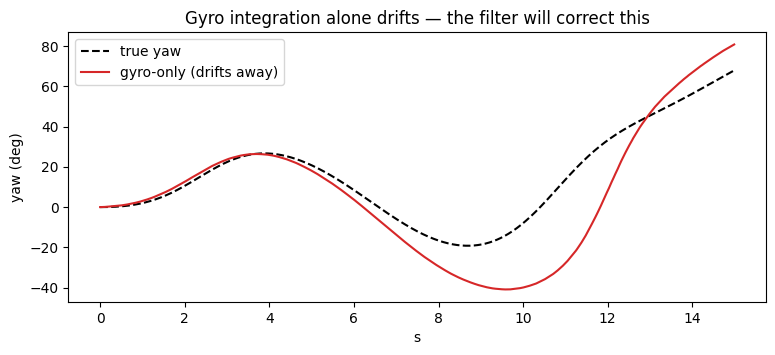

In [16]:
def q_delta(omega, dt):
    '''Small rotation quaternion from an angular-rate vector over dt.'''
    theta = np.linalg.norm(omega)*dt
    if theta < 1e-12: return np.array([1.,0,0,0])
    axis = omega/np.linalg.norm(omega)
    return np.array([np.cos(theta/2), *(axis*np.sin(theta/2))])

T, dt = 15.0, 0.01; t = np.arange(0, T, dt); n = len(t)
true_omega = np.stack([0.5*np.sin(0.6*t), 0.3*np.cos(0.4*t), 0.2*np.sin(0.2*t)], 1)
q_true = np.zeros((n,4)); q_true[0]=[1,0,0,0]
for k in range(1,n): q_true[k] = q_norm(q_mult(q_true[k-1], q_delta(true_omega[k-1], dt)))

bias = np.array([0.03, -0.02, 0.015])                     # constant gyro bias
gyro = true_omega + bias + rng.normal(0, 0.01, (n,3))     # what the chip reports
q_drift = np.zeros((n,4)); q_drift[0]=[1,0,0,0]
for k in range(1,n): q_drift[k] = q_norm(q_mult(q_drift[k-1], q_delta(gyro[k-1], dt)))

def yaw_of(qs): return np.array([np.arctan2(2*(q[0]*q[3]+q[1]*q[2]),
                                            1-2*(q[2]**2+q[3]**2))*DEG for q in qs])
plt.plot(t, yaw_of(q_true), 'k--', label='true yaw')
plt.plot(t, yaw_of(q_drift), 'C3', label='gyro-only (drifts away)')
plt.xlabel('s'); plt.ylabel('yaw (deg)'); plt.legend()
plt.title('Gyro integration alone drifts — the filter will correct this'); plt.show()

# Part E — Making the filter work for an IMU: EKF and UKF

## E1. The problem: the IMU is *nonlinear*

The plain Kalman filter (Part B) assumes everything is **linear** — straight-line relationships you can write as a matrix $\mathbf F$ or $\mathbf H$. But orientation isn't linear: predicting "where does *down* point given this quaternion?" involves sines and cosines. Push a Gaussian (bell curve) through a curvy function and it comes out lopsided — no longer a clean bell — so the basic equations don't apply directly.

Two standard fixes, both of which keep the eight equations and only change *how the curvy parts are handled*:

- **EKF (Extended KF):** approximate each curvy function by its *tangent straight line* at the current guess. The slope of that tangent is the **Jacobian** matrix (just a matrix of partial derivatives = "how each output changes with each input"). Simple and fast; slightly inaccurate if the curve is very bendy.
- **UKF (Unscented KF):** don't approximate the function at all. Instead push a handful of cleverly chosen sample points (**sigma points**) through the *real* function and rebuild the bell curve from where they land. More accurate, no derivatives — at a bit more cost.

We'll build both. They share the same state and the same idea; only the "handle the curve" mechanism differs.

## E2. The IMU filter design (applying everything above)

- **State** $\mathbf x$ (7 numbers): the orientation quaternion + the 3 gyro biases — `[qw,qx,qy,qz, bx,by,bz]`. (Bias is the hidden variable we let the filter learn, exactly like the velocity demo in B4.)
- **Predict** $f(\mathbf x)$: rotate the quaternion with `gyro − bias` (Part D); keep the bias.
- **`Q`**: from your Allan numbers (Part C) — ARW on the orientation block, RRW on the bias block.
- **Correct** $h(\mathbf x)$: predict where **gravity** and **magnetic north** should point in body axes, compare with the (normalised) accel and mag readings.
- **`R`**: accel/mag noise from a static log (Part C).

The two helper reference directions below say where gravity and north live in the world frame.

In [17]:
G_REF = np.array([0., 0., 1.])                      # 'up'/gravity direction in the world
def make_M_REF(inclination_deg=60.0):
    a = np.deg2rad(inclination_deg)
    return q_norm(np.array([np.cos(a), 0.0, np.sin(a)]))   # north + vertical component
M_REF = make_M_REF()

def numerical_jacobian(func, x, eps=1e-6):
    '''The Jacobian = matrix of slopes, found by nudging each input a tiny bit.
       (We compute it numerically so you never have to hand-derive derivatives.)'''
    f0 = func(x); J = np.zeros((len(f0), len(x)))
    for i in range(len(x)):
        dx = np.zeros(len(x)); dx[i] = eps
        J[:, i] = (func(x+dx) - func(x-dx))/(2*eps)
    return J
print("Reference directions and the numerical-Jacobian helper are ready.")

Reference directions and the numerical-Jacobian helper are ready.


## E3. The Extended Kalman Filter, line by line

Below is the whole EKF. It is the Part-B filter with two changes, both highlighted in comments:
1. In **predict**, the state moves through the nonlinear function `f` (quaternion rotation); the covariance uses its Jacobian `F`.
2. In **correct**, the predicted measurement is the nonlinear `h` (gravity/north directions); the covariance uses its Jacobian `H`.

Everything else (`S`, `K`, the updates) is identical to Part B.

In [18]:
class QuaternionEKF:
    def __init__(self, dt, Q=None, R=None):
        self.dt = dt
        self.x = np.array([1.,0,0,0, 0,0,0.])       # start: no rotation, zero bias
        self.P = np.eye(7)*0.01
        self.Q = Q if Q is not None else np.diag([1e-5]*4 + [1e-9]*3)
        self.R = R if R is not None else np.diag([0.05]*3 + [0.08]*3)

    def f(self, x, gyro):                            # nonlinear predict
        q, b = x[:4], x[4:]
        q_new = q_norm(q_mult(q, q_delta(gyro - b, self.dt)))
        return np.concatenate([q_new, b])           # bias unchanged (random walk)

    def h(self, x):                                 # nonlinear measurement
        R = q_to_R(x[:4])
        return np.concatenate([R.T @ G_REF, R.T @ M_REF])   # gravity & north in body axes

    def predict(self, gyro):
        F = numerical_jacobian(lambda x: self.f(x, gyro), self.x)   # <-- Jacobian of f
        self.x = self.f(self.x, gyro); self.x[:4] = q_norm(self.x[:4])
        self.P = F @ self.P @ F.T + self.Q                          # same shape as Part B
    def correct(self, accel, mag):
        z = np.concatenate([accel/np.linalg.norm(accel), mag/np.linalg.norm(mag)])
        H = numerical_jacobian(self.h, self.x)                      # <-- Jacobian of h
        y = z - self.h(self.x)
        S = H @ self.P @ H.T + self.R
        K = self.P @ H.T @ np.linalg.inv(S)
        self.x = self.x + K @ y; self.x[:4] = q_norm(self.x[:4])
        self.P = (np.eye(7) - K @ H) @ self.P
print("QuaternionEKF ready.")

QuaternionEKF ready.


## E4. A simulated IMU so we can check the answer

To *see* the filter work we need to know the truth. This generator makes a smooth true orientation, then fakes a **biased noisy gyro**, an **accelerometer** (gravity + occasional motion bumps), and a **magnetometer** — just like Part D but packaged up.

In [19]:
def simulate_imu(T=20.0, dt=1/100, gyro_bias=(0.03,-0.02,0.015),
                 sg=0.01, sa=0.03, sm=0.02, seed=1):
    r = np.random.default_rng(seed)
    t = np.arange(0,T,dt); n=len(t)
    omega = np.stack([0.8*np.sin(0.5*t), 0.6*np.sin(0.3*t+1), 0.4*np.sin(0.2*t)],1)
    q = np.zeros((n,4)); q[0]=[1,0,0,0]
    for k in range(1,n): q[k]=q_norm(q_mult(q[k-1], q_delta(omega[k-1],dt)))
    b = np.array(gyro_bias)
    gyro = omega + b + r.normal(0,sg,(n,3))
    acc  = np.zeros((n,3)); mag = np.zeros((n,3))
    for k in range(n):
        Rk = q_to_R(q[k])
        acc[k] = Rk.T @ G_REF + r.normal(0,sa,3)
        mag[k] = Rk.T @ M_REF + r.normal(0,sm,3)
    for s in [int(0.35*n), int(0.65*n)]:            # bumps: accel briefly != gravity
        acc[s:s+30] += np.array([0.4,0.3,-0.2])
    return dict(t=t,dt=dt,q_true=q,gyro=gyro,accel=acc,mag=mag,bias=b)

sim = simulate_imu()
print("Simulated", len(sim['t']), "samples; true gyro bias =", sim['bias'])

Simulated 2000 samples; true gyro bias = [ 0.03  -0.02   0.015]


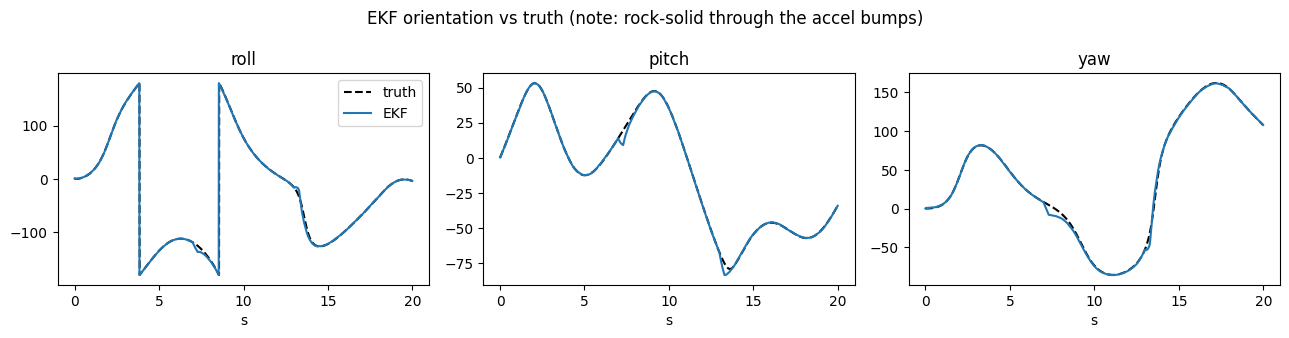

In [20]:
# Run the EKF on the simulated data.
def to_euler(q):
    w,x,y,z=q_norm(q)
    return np.array([np.arctan2(2*(w*x+y*z),1-2*(x*x+y*y)),
                     np.arcsin(np.clip(2*(w*y-z*x),-1,1)),
                     np.arctan2(2*(w*z+x*y),1-2*(y*y+z*z))])*DEG

ekf = QuaternionEKF(sim['dt'])
q_est = np.zeros((len(sim['t']),4)); b_est = np.zeros((len(sim['t']),3))
for k in range(len(sim['t'])):
    ekf.predict(sim['gyro'][k]); ekf.correct(sim['accel'][k], sim['mag'][k])
    q_est[k]=ekf.x[:4]; b_est[k]=ekf.x[4:]

true_e = np.array([to_euler(q) for q in sim['q_true']])
est_e  = np.array([to_euler(q) for q in q_est])
fig,ax=plt.subplots(1,3,figsize=(13,3.4))
for i,name in enumerate(['roll','pitch','yaw']):
    ax[i].plot(sim['t'], true_e[:,i],'k--',label='truth')
    ax[i].plot(sim['t'], est_e[:,i],'C0',label='EKF')
    ax[i].set_title(name); ax[i].set_xlabel('s')
ax[0].legend(); plt.suptitle('EKF orientation vs truth (note: rock-solid through the accel bumps)')
plt.tight_layout(); plt.show()

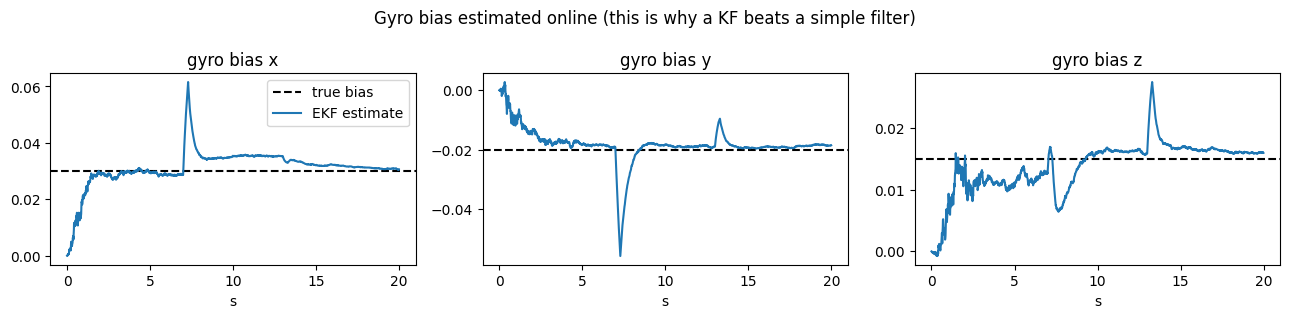

In [21]:
# The payoff: the EKF learns the gyro bias it was never told (the hidden-variable trick).
fig,ax=plt.subplots(1,3,figsize=(13,3.2))
for i,axn in enumerate(['x','y','z']):
    ax[i].axhline(sim['bias'][i],ls='--',color='k',label='true bias')
    ax[i].plot(sim['t'], b_est[:,i],'C0',label='EKF estimate')
    ax[i].set_title(f'gyro bias {axn}'); ax[i].set_xlabel('s')
ax[0].legend(); plt.suptitle('Gyro bias estimated online (this is why a KF beats a simple filter)')
plt.tight_layout(); plt.show()

## E5. The Unscented Kalman Filter (the no-derivatives alternative)

The UKF replaces "approximate the curve by its tangent" with "**sample the curve at a few smart points**". For a 7-number state it picks $2\times7+1 = 15$ **sigma points** arranged around the current guess to capture its mean and covariance, pushes each one through the *real* nonlinear `f`/`h`, and rebuilds the Gaussian from where they land.

You don't tune anything new conceptually — same `Q`, same `R`. The cell is longer only because generating and recombining sigma points takes a few lines. Read the comments; the predict/correct *story* is identical to the EKF.

In [22]:
class QuaternionUKF:
    def __init__(self, dt, Q=None, R=None, alpha=1e-2, beta=2.0, kappa=0.0):
        self.dt=dt; self.n=7
        self.x=np.array([1.,0,0,0,0,0,0.]); self.P=np.eye(7)*0.01
        self.Q = Q if Q is not None else np.diag([1e-6]*4+[1e-10]*3)
        self.R = R if R is not None else np.diag([0.05]*3+[0.08]*3)
        lam=alpha**2*(self.n+kappa)-self.n; c=self.n+lam
        self.Wm=np.full(2*self.n+1,1/(2*c)); self.Wc=self.Wm.copy()
        self.Wm[0]=lam/c; self.Wc[0]=lam/c+(1-alpha**2+beta); self.gamma=np.sqrt(c)
    def _sqrt(self,P):                                   # robust matrix square root
        P=0.5*(P+P.T); w,V=np.linalg.eigh(P); w=np.clip(w,1e-9,None)
        return V@np.diag(np.sqrt(w))@V.T
    def _sigma(self):                                    # the 15 sample points
        S=self._sqrt(self.P); pts=np.zeros((2*self.n+1,self.n)); pts[0]=self.x
        for i in range(self.n):
            pts[i+1]=self.x+self.gamma*S[:,i]; pts[self.n+i+1]=self.x-self.gamma*S[:,i]
        for p in pts: p[:4]=q_norm(p[:4])
        return pts
    def _mean(self,pts):
        ref=pts[0,:4]
        for p in pts:
            if np.dot(p[:4],ref)<0: p[:4]=-p[:4]         # keep quaternions same-sign
        m=self.Wm@pts; m[:4]=q_norm(m[:4]); return m,pts
    def predict(self, gyro):
        pts=self._sigma(); prop=np.zeros_like(pts)
        for i,p in enumerate(pts):                       # push each point through real f
            prop[i,:4]=q_norm(q_mult(p[:4], q_delta(gyro-p[4:], self.dt))); prop[i,4:]=p[4:]
        self.x,prop=self._mean(prop); d=prop-self.x
        self.P=(d.T*self.Wc)@d+self.Q; self.P=0.5*(self.P+self.P.T); self._prop=prop
    def correct(self, accel, mag):
        z=np.concatenate([accel/np.linalg.norm(accel), mag/np.linalg.norm(mag)])
        pts=self._prop; Z=np.array([np.concatenate([q_to_R(p[:4]).T@G_REF,
                                                    q_to_R(p[:4]).T@M_REF]) for p in pts])
        zmean=self.Wm@Z; dz=Z-zmean
        S=(dz.T*self.Wc)@dz+self.R; dx=pts-self.x
        K=((dx.T*self.Wc)@dz)@np.linalg.inv(S)
        self.x=self.x+K@(z-zmean); self.x[:4]=q_norm(self.x[:4])
        self.P=self.P-K@S@K.T; self.P=0.5*(self.P+self.P.T)+1e-12*np.eye(self.n)
print("QuaternionUKF ready.")

QuaternionUKF ready.


            roll   pitch     yaw  total(deg)
EKF         2.33    1.53    2.90        2.32
UKF         2.20    1.04    2.18        1.89


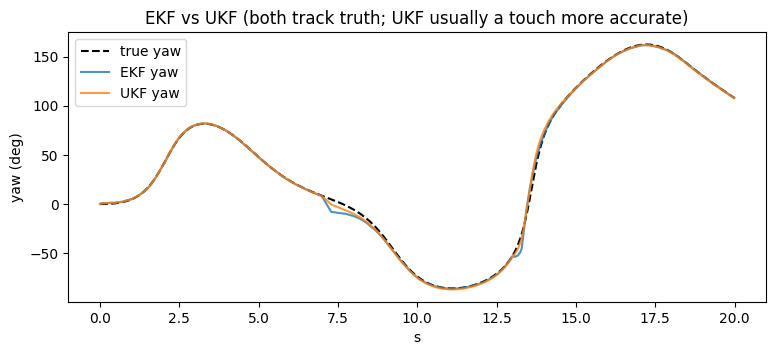

In [23]:
# Run the UKF on the SAME data and compare accuracy with the EKF.
ukf=QuaternionUKF(sim['dt'])
q_ukf=np.zeros((len(sim['t']),4))
for k in range(len(sim['t'])):
    ukf.predict(sim['gyro'][k]); ukf.correct(sim['accel'][k], sim['mag'][k]); q_ukf[k]=ukf.x[:4]
ukf_e=np.array([to_euler(q) for q in q_ukf])

def rmse(est):
    e=(est-true_e+180)%360-180
    return np.sqrt(np.mean(e**2,axis=0))
re_ekf, re_ukf = rmse(est_e), rmse(ukf_e)
print(f"{'':8}{'roll':>8}{'pitch':>8}{'yaw':>8}{'  total(deg)':>12}")
print(f"{'EKF':8}{re_ekf[0]:8.2f}{re_ekf[1]:8.2f}{re_ekf[2]:8.2f}{np.sqrt(np.mean(re_ekf**2)):12.2f}")
print(f"{'UKF':8}{re_ukf[0]:8.2f}{re_ukf[1]:8.2f}{re_ukf[2]:8.2f}{np.sqrt(np.mean(re_ukf**2)):12.2f}")

plt.plot(sim['t'], true_e[:,2],'k--',label='true yaw')
plt.plot(sim['t'], est_e[:,2],'C0',alpha=.8,label='EKF yaw')
plt.plot(sim['t'], ukf_e[:,2],'C1',alpha=.8,label='UKF yaw')
plt.xlabel('s'); plt.ylabel('yaw (deg)'); plt.legend()
plt.title('EKF vs UKF (both track truth; UKF usually a touch more accurate)'); plt.show()

# Part F — How to know your filter is good (and how to tune it)

You have the filter; now the practical loop you'll actually use in your thesis.

**Tuning compass** (only two main knobs, `Q` and `R`):
- `R` too **small** → the filter chases sensor noise (twitchy). `R` too **big** → laggy, ignores the sensor and drifts with the gyro.
- `Q` too **small** → the filter becomes over-confident and can ignore measurements (it "trusts the model too much" and diverges). `Q` too **big** → jittery, never settles.
- Start from your Allan-based `Q`/`R`, then adjust by factors of ~2–10 while watching the checks below.

**Two health checks:**
1. **The surprise (innovation) `y` should look like random noise around zero.** If it has obvious structure/trends, your model (`F`/`H`) or noise (`Q`/`R`) is wrong.
2. **Reject bad measurements (gating).** When the device accelerates, the accelerometer no longer reads pure gravity. Skip the correction when $|\,\|\text{accel}\| - 1g\,|$ is too large. This one trick massively improves real-world robustness.

Rejected 30 corrupted measurements (during the bumps).


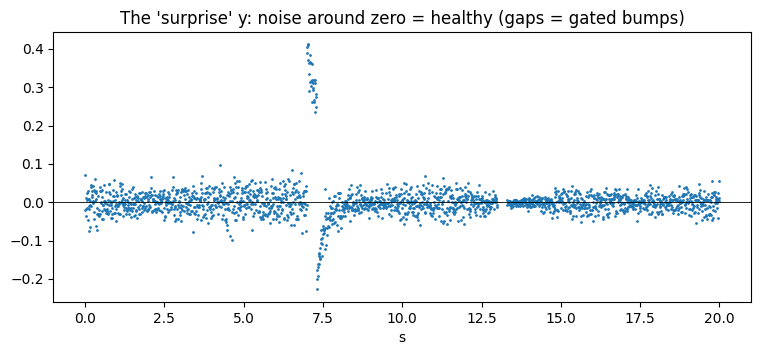

In [24]:
# Gating demo: skip the accel/mag correction during the linear-acceleration bumps.
ekf = QuaternionEKF(sim['dt'])
skipped = 0; surprise = []
for k in range(len(sim['t'])):
    ekf.predict(sim['gyro'][k])
    if abs(np.linalg.norm(sim['accel'][k]) - 1.0) < 0.2:   # gate: accel ~ 1 g ?
        z = np.concatenate([sim['accel'][k]/np.linalg.norm(sim['accel'][k]),
                            sim['mag'][k]/np.linalg.norm(sim['mag'][k])])
        surprise.append((z - ekf.h(ekf.x))[0]); ekf.correct(sim['accel'][k], sim['mag'][k])
    else:
        skipped += 1; surprise.append(np.nan)
print(f"Rejected {skipped} corrupted measurements (during the bumps).")
plt.plot(sim['t'], surprise, '.', ms=2); plt.axhline(0,color='k',lw=.6)
plt.title("The 'surprise' y: noise around zero = healthy (gaps = gated bumps)")
plt.xlabel('s'); plt.show()

# Part G — One-page recap

**The idea.** Keep a guess + its uncertainty (a Gaussian). Each step **predict** (model moves the guess, uncertainty grows) then **correct** (a measurement pulls the guess in, uncertainty shrinks). The pull is the **Kalman gain**, an automatic trust-weighting between model and sensor.

**The 8 equations** (predict 2, correct: surprise, surprise-cov, gain, two updates). You only *design* four things:
- `F` — how the state moves (for an IMU: quaternion rotation by the gyro).
- `H` — what the sensor sees (for an IMU: where gravity/north point).
- `Q` — process noise, **from your Allan ARW (orientation) and RRW (bias)**: $Q_\text{angle}\!=\!\text{ARW}^2\Delta t$, $Q_\text{bias}\!=\!\text{RRW}^2\Delta t$.
- `R` — measurement noise, **from a static-rest variance** (or VRW).

**Quaternion** = `[cos(θ/2), axis·sin(θ/2)]`; build it from an axis + angle; chain small ones from the gyro to predict orientation; no gimbal lock.

**Nonlinear IMU** → **EKF** (approximate curves by their tangent = Jacobian) or **UKF** (sample the curve at sigma points, no derivatives). Both estimate **gyro bias** as a hidden state.

**Make it work:** start with Allan-based `Q`/`R`, tune by watching the surprise `y`, and **gate** the accelerometer when the device accelerates.

### Where to read more
- R. Labbé, *Kalman and Bayesian Filters in Python* (free, the gentlest deep-dive) — https://github.com/rlabbe/Kalman-and-Bayesian-Filters-in-Python
- J. Solà, *Quaternion kinematics for the error-state Kalman filter*, arXiv:1711.02508 — the quaternion reference.
- Kalibr IMU-noise model (the continuous↔discrete conversion) — https://github.com/ethz-asl/kalibr/wiki/IMU-Noise-Model
- `ahrs` Python library (EKF/UKF/Madgwick/Mahony, documented) — https://ahrs.readthedocs.io
- Marins & Yun, *An EKF for Quaternion-Based Orientation Estimation Using MARG Sensors* (the 7-state filter we built).

*All code here is original, minimal, and meant for learning. For production use `filterpy` or `ahrs`.*